UTS Data Science

Nama : Novika Ardiyaningtyas

*   Nama : Novika Ardiyaningtyas
*   NIM : 250401020135
*   Kelas: IF401


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', palette='muted')

# Load Dataset
df = sns.load_dataset('diamonds')

print('Shape Dataset:', df.shape)

print('\nTipe Kolom:')
print(df.dtypes)

print('\nStatistik Deskriptif:')
print(df.describe().round(2))

print('\nMissing Values:')
print(df.isnull().sum())

print('\nJumlah Data per Cut:')
print(df['cut'].value_counts())

print('\nJumlah Data per Color:')
print(df['color'].value_counts())

Shape Dataset: (53940, 10)

Tipe Kolom:
carat       float64
cut        category
color      category
clarity    category
depth       float64
table       float64
price         int64
x           float64
y           float64
z           float64
dtype: object

Statistik Deskriptif:
          carat     depth     table     price         x         y         z
count  53940.00  53940.00  53940.00  53940.00  53940.00  53940.00  53940.00
mean       0.80     61.75     57.46   3932.80      5.73      5.73      3.54
std        0.47      1.43      2.23   3989.44      1.12      1.14      0.71
min        0.20     43.00     43.00    326.00      0.00      0.00      0.00
25%        0.40     61.00     56.00    950.00      4.71      4.72      2.91
50%        0.70     61.80     57.00   2401.00      5.70      5.71      3.53
75%        1.04     62.50     59.00   5324.25      6.54      6.54      4.04
max        5.01     79.00     95.00  18823.00     10.74     58.90     31.80

Missing Values:
carat      0
cut      

Dataset Diamonds telah dimuat dan dipelajari dengan baik. Hasil pemeriksaan menunjukkan jumlah data, jenis data untuk setiap kolom, dan statistik deskriptif dasar. Dataset terdiri dari variabel numerik dan kategorik, yang dapat digunakan untuk menganalisis harga berlian berdasarkan atributnya.

/tmp/ipykernel_2115/2119437353.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_price = df.groupby('cut')['price'].mean().reindex(urutan_cut)


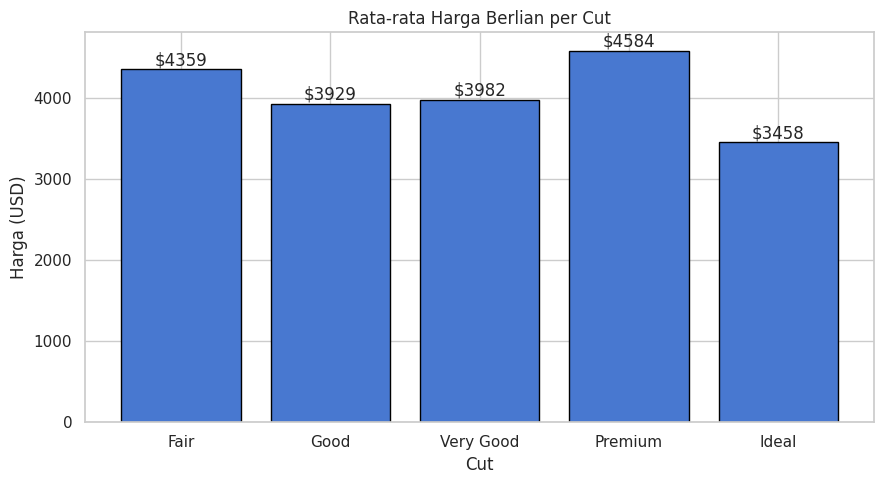

In [2]:
urutan_cut = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']

fig, ax = plt.subplots(figsize=(9,5))

avg_price = df.groupby('cut')['price'].mean().reindex(urutan_cut)

bars = ax.bar(
    avg_price.index,
    avg_price.values,
    edgecolor='black'
)

ax.bar_label(bars, fmt='$%.0f')

ax.set_title('Rata-rata Harga Berlian per Cut')
ax.set_xlabel('Cut')
ax.set_ylabel('Harga (USD)')

plt.tight_layout()
plt.show()

Setiap kategori cut menunjukkan perbedaan harga rata-rata berlian. Dengan melihat visualisasi ini, Anda dapat menemukan kategori cut dengan harga rata-rata tertinggi dan terendah, yang memudahkan perbandingan antar kelompok.

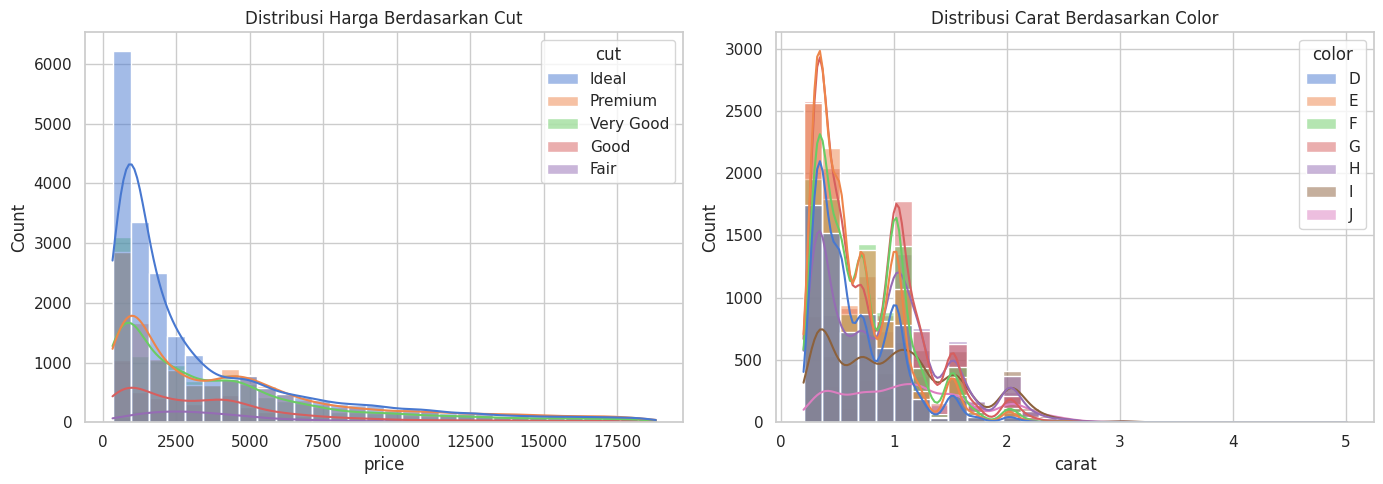

In [3]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

sns.histplot(
    data=df,
    x='price',
    hue='cut',
    kde=True,
    bins=30,
    ax=axes[0]
)

axes[0].set_title('Distribusi Harga Berdasarkan Cut')

sns.histplot(
    data=df,
    x='carat',
    hue='color',
    kde=True,
    bins=30,
    ax=axes[1]
)

axes[1].set_title('Distribusi Carat Berdasarkan Color')

plt.tight_layout()
plt.show()

Histogram menunjukkan ukuran carat dan distribusi harga berlian. Sebagian besar data terkonsentrasi dalam rentang tertentu, tetapi data dengan nilai yang sangat tinggi lebih sedikit. Visualisasi ini meningkatkan pemahaman tentang pola penyebaran data.

/tmp/ipykernel_2115/382270956.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


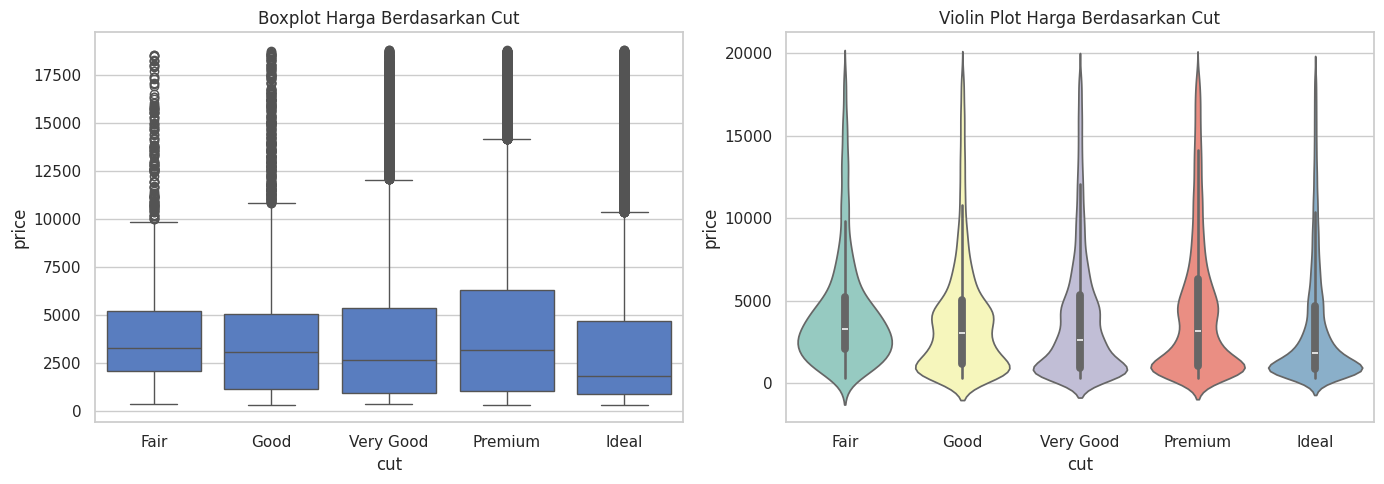

In [4]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

sns.boxplot(
    data=df,
    x='cut',
    y='price',
    order=urutan_cut,
    ax=axes[0]
)

axes[0].set_title('Boxplot Harga Berdasarkan Cut')

sns.violinplot(
    data=df,
    x='cut',
    y='price',
    order=urutan_cut,
    palette='Set3',
    ax=axes[1]
)

axes[1].set_title('Violin Plot Harga Berdasarkan Cut')

plt.tight_layout()
plt.show()

Boxplot dan violin plot menunjukkan perbedaan distribusi harga di setiap kategori cut. Selain menunjukkan nilai median dan rentang data, visualisasi ini juga membantu menemukan variasi harga dan kemungkinan adanya outlier di masing-masing kategori.

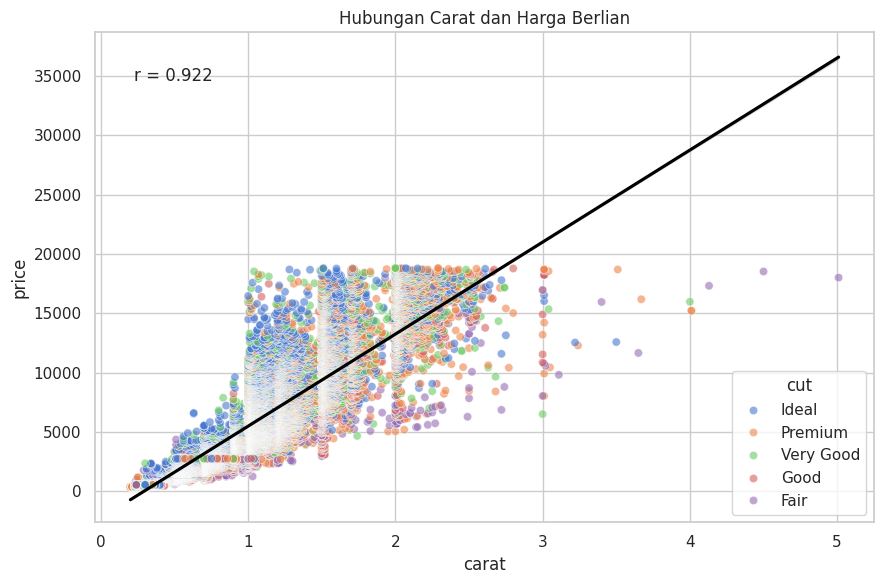

In [5]:
fig, ax = plt.subplots(figsize=(9,6))

sns.scatterplot(
    data=df,
    x='carat',
    y='price',
    hue='cut',
    alpha=0.6,
    ax=ax
)

sns.regplot(
    data=df,
    x='carat',
    y='price',
    scatter=False,
    color='black',
    ax=ax
)

r, p = stats.pearsonr(df['carat'], df['price'])

ax.text(
    0.05,
    0.9,
    f'r = {r:.3f}',
    transform=ax.transAxes,
    fontsize=12
)

ax.set_title('Hubungan Carat dan Harga Berlian')

plt.tight_layout()
plt.show()

Scatter plot menunjukkan bahwa ada korelasi positif antara harga berlian dan carat. Nilai korelasi yang diperoleh menunjukkan bahwa ada korelasi yang kuat antara kedua variabel tersebut.

/tmp/ipykernel_2115/1133795232.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_price = df.groupby('cut')['price'].mean().reindex(urutan_cut)
/tmp/ipykernel_2115/1133795232.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


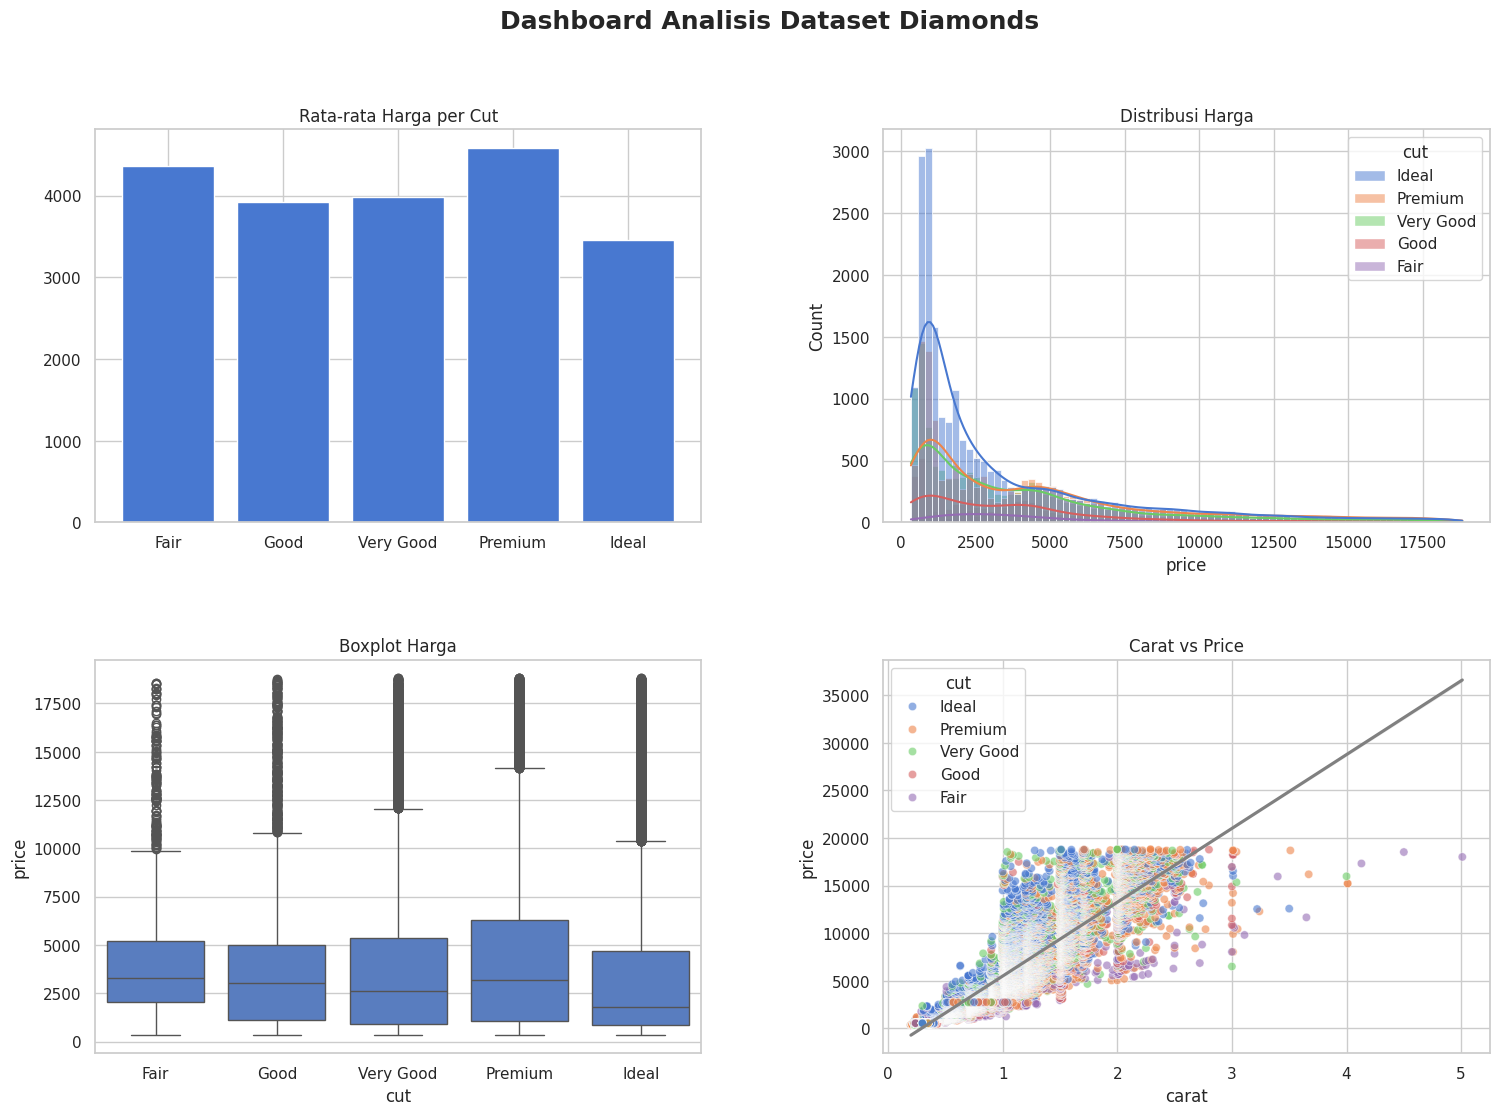

✅ Dashboard berhasil dibuat!


In [6]:
fig = plt.figure(figsize=(18,12))

fig.suptitle(
    'Dashboard Analisis Dataset Diamonds',
    fontsize=18,
    fontweight='bold'
)

gs = gridspec.GridSpec(
    2,2,
    figure=fig,
    hspace=0.35,
    wspace=0.30
)

ax1 = fig.add_subplot(gs[0,0])
ax2 = fig.add_subplot(gs[0,1])
ax3 = fig.add_subplot(gs[1,0])
ax4 = fig.add_subplot(gs[1,1])

# Grafik 1
avg_price = df.groupby('cut')['price'].mean().reindex(urutan_cut)
ax1.bar(avg_price.index, avg_price.values)
ax1.set_title('Rata-rata Harga per Cut')

# Grafik 2
sns.histplot(
    data=df,
    x='price',
    hue='cut',
    kde=True,
    ax=ax2
)
ax2.set_title('Distribusi Harga')

# Grafik 3
sns.boxplot(
    data=df,
    x='cut',
    y='price',
    order=urutan_cut,
    ax=ax3
)
ax3.set_title('Boxplot Harga')

# Grafik 4
sns.scatterplot(
    data=df,
    x='carat',
    y='price',
    hue='cut',
    alpha=0.6,
    ax=ax4
)

sns.regplot(
    data=df,
    x='carat',
    y='price',
    scatter=False,
    color='gray',
    ax=ax4
)

ax4.set_title('Carat vs Price')

plt.tight_layout()
plt.show()

print('✅ Dashboard berhasil dibuat!')

Dashboard memudahkan analisis dengan menggabungkan seluruh visualisasi dalam satu tampilan. Pola distribusi harga, perbedaan antar kategori cut, dan hubungan antara harga berlian dan ukuran carat dapat dilihat lebih jelas di dashboard.

Kesimpulan: Dalam praktikum ini Python digunakan untuk mengeksplorasi dan memvisualisasikan dataset Diamonds. Beberapa karakteristik berlian, terutama ukuran carat dan kualitas cut, memengaruhi harga berlian, menurut analisis. Visualisasi juga membantu memahami distribusi data, perbedaan antar kategori, dan hubungan antar variabel. Karena analisis ini masih bersifat eksploratif dan tidak menggunakan metode pemodelan atau prediksi, analisis lanjutan dapat dilakukan untuk mengetahui faktor yang paling berpengaruh terhadap harga berlian. Ini dapat dilakukan dengan menggunakan teknik machine learning atau statistik.